In [ ]:
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from utils.data import load_npz_data

simulation_number = 0
all_features = []
labels = []
for i in range(10):
    d = load_npz_data(f"data/datasets/TON_IoT_10n_3k/0/4inTestBalancedAlpha02/node_{i}.npz")
    #feat = d[0][:, 0]
    feat = d[1][:]
    all_features.extend(feat)
    labels.extend([f"node_{i}"] * len(feat))

plt.figure(figsize=(15,10))
sns.violinplot(x=labels, y=all_features, inner="quartile", width=1)
path_folder = Path("experiments/TON_IoT/") / f"{simulation_number}" / "testing_unified"
#plt.savefig(Path(path_folder) / "violin_plot_node_distribution.jpg")
plt.show()

In [ ]:
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from utils.data import load_npz_data

simulation_number = 0
all_features = []
labels = []
for i in range(10):
    d = load_npz_data(f"data/datasets/TON_IoT_2n_1k/0/4inTestSplit/node_{i}.npz")
    #feat = d[0][:, 0]
    feat = d[5][:]
    all_features.extend(feat)
    labels.extend([f"node_{i}"] * len(feat))

plt.figure(figsize=(15,10))
sns.violinplot(x=labels, y=all_features, inner="quartile", width=1)
path_folder = Path("experiments/TON_IoT/") / f"{simulation_number}" / "testing_unified"
#plt.savefig(Path(path_folder) / "violin_plot_node_distribution.jpg")
plt.show()

In [ ]:
bg = load_npz_data(f"data/datasets/TON_IoT_10n_3k/0/4inTestBalancedAlpha02/node_6.npz")

print("train: ", len(bg[1]))
print("val: ", len(bg[3]))
print("test: ", len(bg[5]))

print("Tot: ", len(bg[1]) + len(bg[3]) + len(bg[5]))


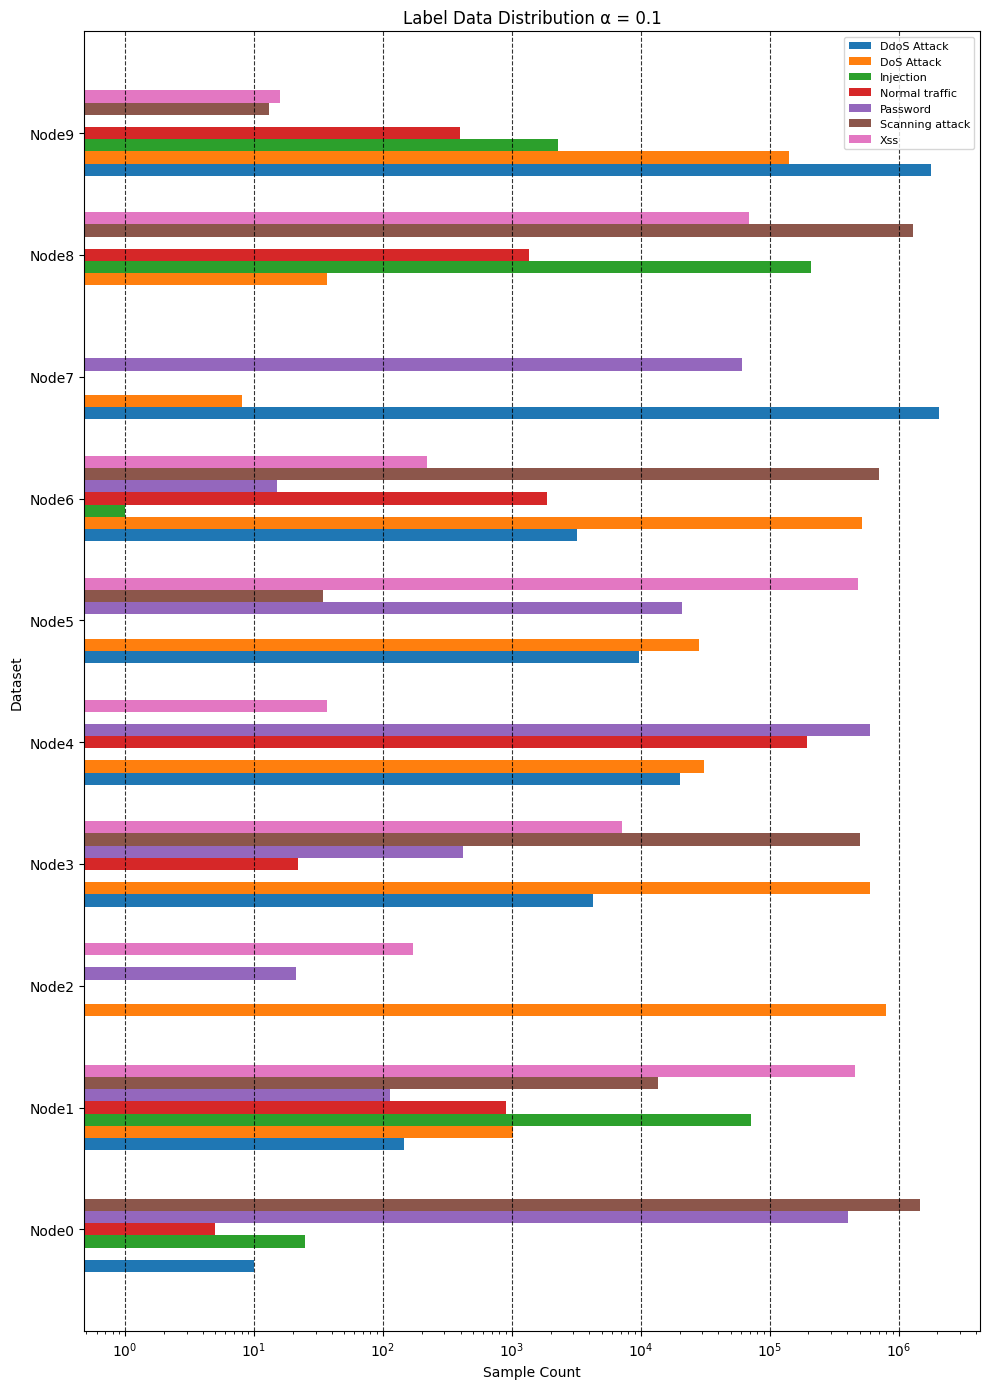

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from utils.data import load_npz_data

label_counts = []
model_names = []
alpha = 1

for i in range(10):
    d = load_npz_data(f"data/datasets/TON_IoT_10n_3k/0/4inTestBalancedAlpha0{alpha}_seedRand/node_{i}.npz")
    #feat = d[0][:, 0]
    feat = d[1][:]

    #labels = d.astype(int)
    counts = np.bincount(feat, minlength=7)

    label_counts.append(counts)
    model_names.append(f"Node{i}")

label_counts = np.array(label_counts)

plt.figure(figsize=(10, 14))

y = np.arange(len(model_names))
height = 0.1

label_dict = {
    'DdoS Attack': np.int64(0),
    'DoS Attack': np.int64(1),
    'Injection': np.int64(2),
    'Normal traffic': np.int64(3),
    'Password': np.int64(4),
    'Scanning attack': np.int64(5),
    'Xss': np.int64(6)
}

inverse_dict = {int(v): k for k, v in label_dict.items()}

for cls, class_name in sorted(inverse_dict.items()):
    plt.barh(
        y + cls * height,
        label_counts[:, cls],
        height,
        label=class_name
    )

plt.yticks(y + height * 3, model_names)
plt.xlabel("Sample Count", fontsize=20)
plt.ylabel("Dataset", fontsize=20)
plt.title(f"Label Data Distribution α = 0.{alpha}")
plt.xscale("log")
plt.grid(axis="x", which="major", linestyle="--", alpha=0.8, color='k')
plt.legend(fontsize="large")
plt.tight_layout()
plt.show()
